In [1]:
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu116

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116



[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...


In [2]:
!cd yolov5 & pip install -r requirements.txt


[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import cv2

In [4]:
import uuid   # Unique identifier
import os
import time

In [6]:
IMAGES_PATH = os.path.join('data', 'images') #/data/images
labels = ['cotton']
number_imgs = 27

In [11]:
import os
import uuid

# Path to the folder containing the images
# folder_path = "/path/to/folder"

# Get a list of all files in the folder
file_list = os.listdir(IMAGES_PATH)

# Loop through each file and rename it to a unique identifier
for file_name in file_list:
    # Only rename files that are images
    if file_name.endswith(".jpg") or file_name.endswith(".png") or file_name.endswith(".jpeg"):
        # Generate a new file name using a UUID
        new_file_name = 'cotton.'+str(uuid.uuid4()) + os.path.splitext(file_name)[1]
        # Build the full path to the file
        old_file_path = os.path.join(IMAGES_PATH, file_name)
        new_file_path = os.path.join(IMAGES_PATH, new_file_name)
        # Rename the file
        os.rename(old_file_path, new_file_path)



In [12]:
!git clone https://github.com/tzutalin/labelImg

Cloning into 'labelImg'...


In [5]:
!pip install pyqt5 lxml --upgrade
!cd labelImg && pyrcc5 -o libs/resources.py resources.qrc

Could not fetch URL https://pypi.org/simple/pyqt5/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pyqt5/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self signed certificate in certificate chain (_ssl.c:1129)'))) - skipping
Could not fetch URL https://pypi.org/simple/lxml/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/lxml/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self signed certificate in certificate chain (_ssl.c:1129)'))) - skipping



[notice] A new release of pip available: 22.3.1 -> 23.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!cd yolov5 && python train.py --img 320 --batch 16 --epochs 500 --data dataset.yml --weights yolov5s.pt --workers 2

train: weights=yolov5s.pt, cfg=, data=dataset.yml, hyp=data\hyps\hyp.scratch-low.yaml, epochs=500, batch_size=16, imgsz=320, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=2, project=runs\train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 
fatal: cannot change to 'C:\Users\user\OneDrive\Desktop\E': No such file or directory
YOLOv5  2023-2-16 Python-3.9.7 torch-1.13.1+cpu CPU

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0,

In [6]:
model = torch.hub.load('ultralytics/yolov5', 'custom', path='yolov5/runs/train/exp14/weights/last.pt', force_reload=True)

Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to C:\Users\user/.cache\torch\hub\master.zip
YOLOv5  2023-2-16 Python-3.9.7 torch-1.13.1+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7053277 parameters, 0 gradients, 15.9 GFLOPs
Adding AutoShape... 


In [11]:
img = os.path.join('data', 'images', 'cotton.57fc3779-8552-40a3-9c17-03093632459d.jpg')

In [12]:
results = model(img)

In [13]:
results.print()

image 1/1: 192x262 2 cottons
Speed: 6.7ms pre-process, 216.7ms inference, 0.0ms NMS per image at shape (1, 3, 480, 640)


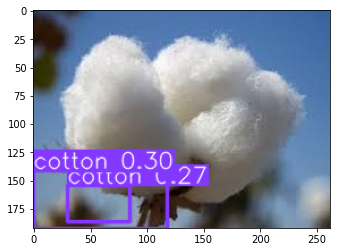

In [14]:
%matplotlib inline 
plt.imshow(np.squeeze(results.render()))
plt.show()

In [16]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
    ret, frame = cap.read()
    
    # Make detections 
    results = model(frame)
    
    cv2.imshow('YOLO', np.squeeze(results.render()))
    
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()